In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import expm, expm_multiply
from numpy.linalg import eigh
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from sympy import Matrix
import cvxpy as cp
import random

import h5py

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],   # default LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 15, 
})

In [2]:
with h5py.File("slater_matrices_1088.hdf5", "r") as slater_file:
    slater_matrices_eng = slater_file["slater_matrices_eng"][...]
    slater_matrices_exact = slater_file["slater_matrices_exact"] [...]
    trotter_steps = slater_file["trotter_steps"] [...]
    time_steps_eng = slater_file["time_steps"][...]
    time_steps_exact = slater_file["time_steps_exact"][...]
    matching_indices = slater_file["matching_indices"][...]

    slater_file.close()

In [3]:
infidelities = [[[] for _ in range(len(time_steps_eng))] for _ in range(len(trotter_steps))]
for i in range(len(trotter_steps)):
    for j in range(len(time_steps_eng)):
        overlap = np.linalg.det(slater_matrices_exact[matching_indices[j]].conj().T@slater_matrices_eng[i,j])
        fidelity = np.abs(overlap)**2
        infidelities[i][j] = 1-fidelity
infidelities = np.array(infidelities)

In [4]:
infidelities[9]

array([-6.15061477e-07,  5.73239784e-04,  1.71224882e-03,  5.85808486e-03,
        2.22782661e-02,  7.17405971e-02,  1.88200748e-01])

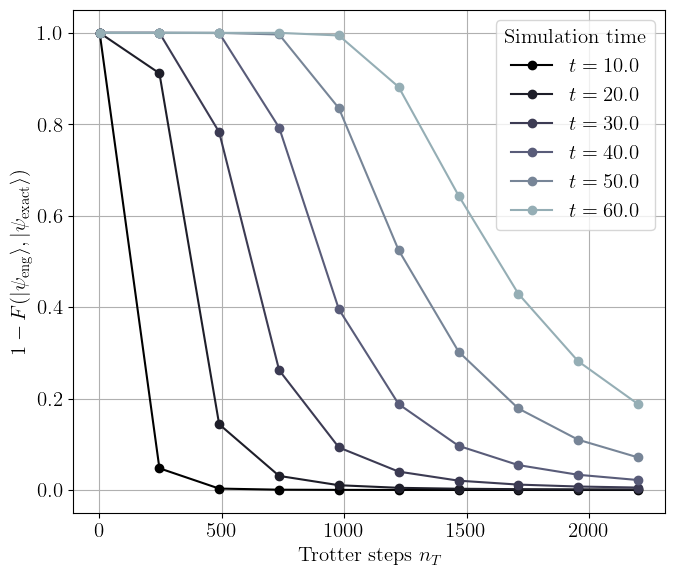

In [11]:

plt.figure(figsize=(7,6))
plt.grid()    

cmap = plt.cm.bone
colors = cmap(np.linspace(0, 0.8,len(time_steps_eng)))


for j in range(len(time_steps_eng)-1):
    plt.plot(trotter_steps,infidelities[:,j+1],"o-",color = colors[j],label = fr"$t ={np.round(time_steps_eng[j+1])}$",)  
plt.legend(title = 'Simulation time')
plt.xlabel(r"Trotter steps $n_T$")
plt.ylabel(r"$1-F(|\psi_\mathrm{eng}\rangle,|\psi_\mathrm{exact}\rangle)$")
# plt.yscale("log")   # optional, often useful for infidelities
plt.tight_layout()
plt.savefig("infidelity_HH.pdf",bbox_inches = 'tight', dpi =300, format ='pdf')
plt.show()